In [1]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [13]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape)


CSV dimensions:  (144, 2)


In [23]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.set_index('date', inplace=True)
csv_data.head()

,n_passengers
date,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


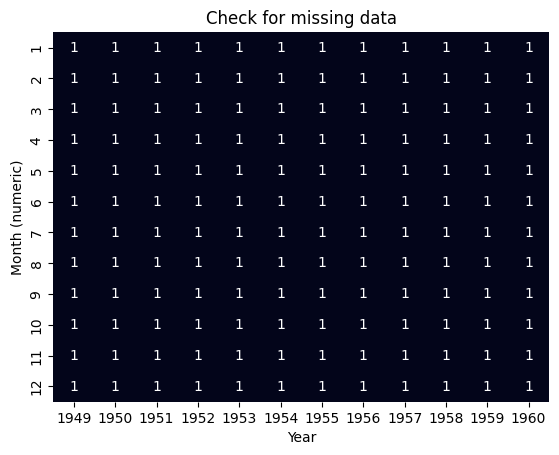

In [25]:
heat_dt1 = csv_data.copy().reset_index()
heat_dt1["status"] = heat_dt1['n_passengers'].apply(lambda x: 1 if x>0 and x is not None else 0)
heat_dt1["month"]  = heat_dt1['date'].apply(lambda x: x.split('-')[1]).astype(int)
heat_dt1["year"]   = heat_dt1['date'].apply(lambda x: x.split('-')[0]).astype(int)

heat_dt2 = pd.DataFrame(heat_dt1, columns=['status','month','year']).set_index(['month','year']).\
            pivot_table(index='month', columns='year', values='status')

# heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)
plt. title("Check for missing data")
plt.xlabel("Year")
plt.ylabel("Month (numeric)")
plt.show()

In [22]:
csv_data.head()

,date,n_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


AttributeError: 'Figure' object has no attribute 'items'

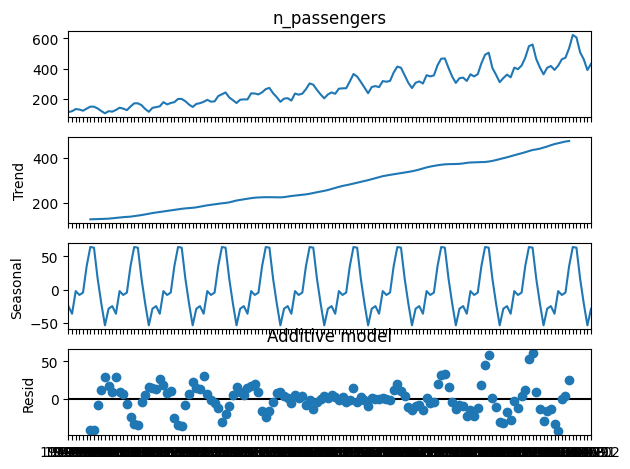

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp1 = seasonal_decompose(csv_data['n_passengers'], period=12, model='additive')
add_fig = decomp1.plot()
add_fig.suptitle("Additive model")
plt.show()

decomp2 = seasonal_decompose(csv_data['n_passengers'], period=12, model='multiplicative')
mul_fig = decomp2.plot()
mul_fig.suptitle("Multiplicative model")
plt.show()